In [1]:
from classifiers import load_split, build_model, train, predict
from tokenization import compare_tokenizers_on_text
from sklearn.metrics import accuracy_score, f1_score
import random
import pandas as pd

In [2]:
# loading training, dev, and test data
train_texts, train_labels = load_split("train")
dev_texts, dev_labels = load_split("dev")
test_texts, test_labels = load_split("test")

print(len(train_texts), len(dev_texts), len(test_texts))

1400 250 250


In [3]:
import random

random.seed(100)
# sample 5 random review indices from the training set
sample_indices = random.sample(range(len(train_texts)), 5)

# for each ranomly selected review from the training set, tokenize using all 4 chosen tokenization methods,
# showing the differences between them
for i in range(5):
    text = train_texts[sample_indices[i]]
    
    print("\n------SAMPLE", i + 1, "-------")
    print("ACUTAL TEXT:", text[:400], "...\n")
    
    result = compare_tokenizers_on_text(text)
    
    print("split:")
    print(result["split"][:60])
    print()
    
    print("toktok:")
    print(result["toktok"][:60])
    print()
    
    print("word_tokenize:")
    print(result["word_tokenize"][:60])
    print()
    
    print("wordpunct:")
    print(result["wordpunct"][:60])
    print()


------SAMPLE 1 -------
ACUTAL TEXT: on paper, this movie would sound incredibly boring. the idea of a 75-year-old man traveling the country-side on a riding mower certainly doesn't have much appeal to it, but the real power behind the film is its charm and its intelligence. writers will not find a better study of what makes a movie work than "the straight story." the perfect example of this is a scene in which alvin meets a runaway  ...

split:
['on', 'paper,', 'this', 'movie', 'would', 'sound', 'incredibly', 'boring.', 'the', 'idea', 'of', 'a', '75-year-old', 'man', 'traveling', 'the', 'country-side', 'on', 'a', 'riding', 'mower', 'certainly', "doesn't", 'have', 'much', 'appeal', 'to', 'it,', 'but', 'the', 'real', 'power', 'behind', 'the', 'film', 'is', 'its', 'charm', 'and', 'its', 'intelligence.', 'writers', 'will', 'not', 'find', 'a', 'better', 'study', 'of', 'what', 'makes', 'a', 'movie', 'work', 'than', '"the', 'straight', 'story."', 'the', 'perfect']

toktok:
['on', 'paper', ',

In [4]:

vectorizer, clf = build_model(
    model_type="logreg",
    vectorizer_type="tfidf",
    tokenizer_method="split"
)

train(vectorizer, clf, train_texts, train_labels)
dev_preds = predict(vectorizer, clf, dev_texts)

# Visualizaion/Conparison of Results:

Best config: model=svm, vectorizer=tfidf, tokenizer=word_tokenize, acc=0.8680


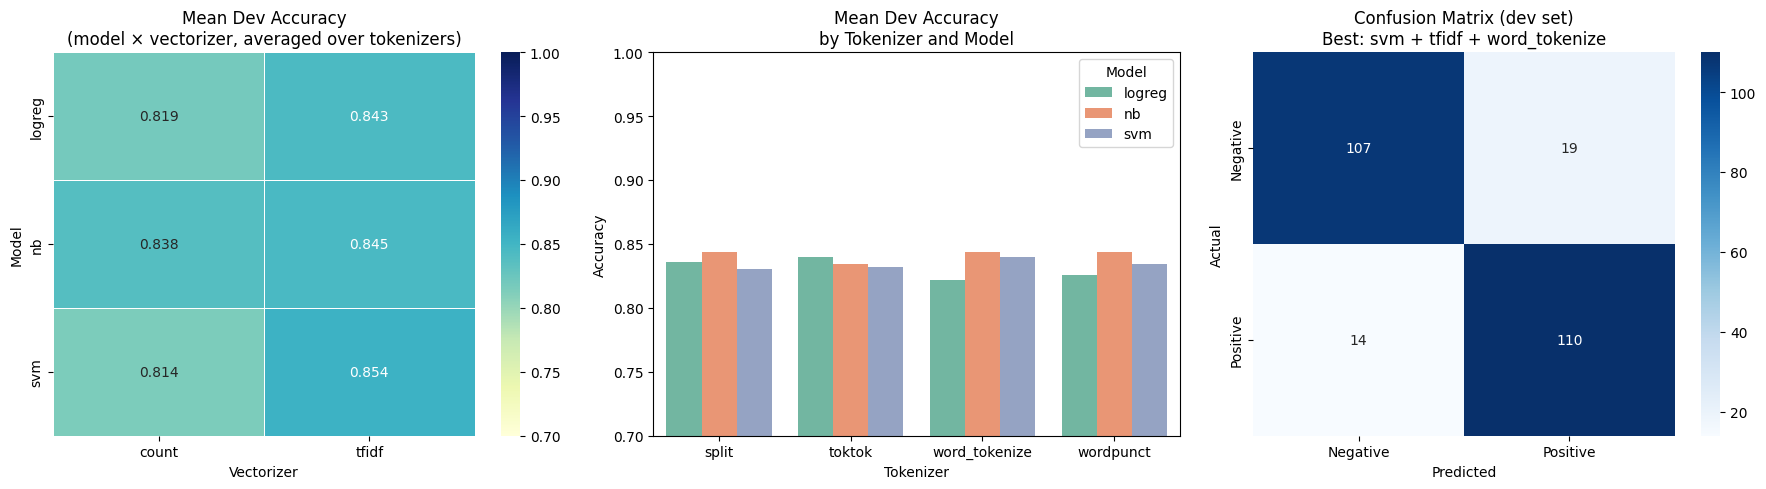

In [ ]:
#Visualization/Analysis of results:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Run all combinations ---
model_types     = ["logreg", "svm", "nb"]
vectorizer_types = ["tfidf", "count"]
tokenizer_methods = ["split", "toktok", "word_tokenize", "wordpunct"]

results = []
for tok in tokenizer_methods:
    for vec in vectorizer_types:
        for mod in model_types:
            vectorizer, clf = build_model(
                model_type=mod,
                vectorizer_type=vec,
                tokenizer_method=tok,
            )
            train(vectorizer, clf, train_texts, train_labels)
            dev_preds = predict(vectorizer, clf, dev_texts)
            acc = accuracy_score(dev_labels, dev_preds)
            results.append({"tokenizer": tok, "vectorizer": vec, "model": mod, "accuracy": acc})

results_df = pd.DataFrame(results)

# --- 1. Heatmap: model × vectorizer (averaged over tokenizers) ---
pivot = results_df.groupby(["model", "vectorizer"])["accuracy"].mean().unstack()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    pivot,
    annot=True, fmt=".3f", cmap="YlGnBu",
    linewidths=0.5, vmin=0.7, vmax=1.0,
    ax=axes[0],
)
axes[0].set_title("Mean Dev Accuracy\n(model × vectorizer, averaged over tokenizers)")
axes[0].set_xlabel("Vectorizer")
axes[0].set_ylabel("Model")

# --- 2. Grouped bar chart: accuracy by model × tokenizer ---
pivot2 = results_df.groupby(["model", "tokenizer"])["accuracy"].mean().reset_index()
sns.barplot(
    data=pivot2,
    x="tokenizer", y="accuracy", hue="model",
    palette="Set2", ax=axes[1],
)
axes[1].set_title("Mean Dev Accuracy\nby Tokenizer and Model")
axes[1].set_xlabel("Tokenizer")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.7, 1.0)
axes[1].legend(title="Model")

# --- 3. Confusion matrix for the best model on the dev set ---
best_row = results_df.loc[results_df["accuracy"].idxmax()]
print(f"Best config: model={best_row['model']}, vectorizer={best_row['vectorizer']}, tokenizer={best_row['tokenizer']}, acc={best_row['accuracy']:.4f}")

best_vec, best_clf = build_model(
    model_type=best_row["model"],
    vectorizer_type=best_row["vectorizer"],
    tokenizer_method=best_row["tokenizer"],
)
train(best_vec, best_clf, train_texts, train_labels)
best_preds = predict(best_vec, best_clf, dev_texts)

cm = confusion_matrix(dev_labels, best_preds)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[2],
)
axes[2].set_title(f"Confusion Matrix (dev set)\nBest: {best_row['model']} + {best_row['vectorizer']} + {best_row['tokenizer']}")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()
